https://www.ice.gov/detain/detention-management

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from dotenv import load_dotenv
from qbstyles import mpl_style
import pytidycensus as tc
from concurrent.futures import ThreadPoolExecutor
from typing import Dict, Literal, List, Union
import glob
import warnings
from pygris import counties
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")


%config InlineBackend.figure_format = 'retina'

mpl_style(dark=True)

load_dotenv()

API_KEY: str = os.getenv("CENSUS_KEY")
DATA: str = os.getenv("DATA")

tc.set_census_api_key(API_KEY)

pd.set_option('display.precision', 2)



Census API key has been set for this session.


/tmp/ipykernel_210997/403056924.py:7: UserWarning: Mapping functions unavailable due to import error: NameError. To use mapping features, ensure all dependencies are properly installed: pip install pytidycensus[map]
  import pytidycensus as tc


# RUCC Data

::: {.callout-note}
## Overview
The 2023 Rural-Urban Continuum Codes distinguish U.S. metropolitan (metro) counties by the population size of their metro area, and nonmetropolitan (nonmetro) counties by their degree of urbanization and adjacency to a metro area. The division of counties as either metro or nonmetro, based on the 2023 Office of Management and Budget (OMB) delineation of metro areas, is further subdivided into three metro and six nonmetro categories. Each county and census-designated county-equivalent in the United States, including those in outlying territories, is assigned one of these nine codes. The codes allow researchers, policy makers, and others to view county-level data by finer residential groups—beyond metro and nonmetro—when analyzing trends related to population density and metro influence.

*See: [USDA Rural-Urban Continuum Codes Overview](https://www.ers.usda.gov/data-products/rural-urban-continuum-codes) for more information and the [Center for Rural Policy and Development](https://www.ruralmn.org/an-update-to-rural-urban-continuum-codes/) article on the implications of the new RUCC codes*
:::

In [2]:
# | label: tbl-rural-codes
# | tbl-cap: "Rural-Urban Continuum Codes"

data = {
    "Code": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "Description": [
        "Counties in metro areas of 1 million population or more",
        "Counties in metro areas of 250,000 to 1 million population",
        "Counties in metro areas of fewer than 250,000 population",
        "Urban population of 20,000 or more, adjacent to a metro area",
        "Urban population of 20,000 or more, not adjacent to a metro area",
        "Urban population of 5,000 to 20,000, adjacent to a metro area",
        "Urban population of 5,000 to 20,000, not adjacent to a metro area",
        "Urban population of fewer than 5,000, adjacent to a metro area",
        "Urban population of fewer than 5,000, not adjacent to a metro area",
    ],
    "Category": ["Metropolitan"] * 3 + ["Nonmetropolitan"] * 6,
}

df = pd.DataFrame(data)

df


,Code,Description,Category
0,1,Counties in metro areas of 1 million populatio...,Metropolitan
1,2,"Counties in metro areas of 250,000 to 1 millio...",Metropolitan
2,3,"Counties in metro areas of fewer than 250,000 ...",Metropolitan
3,4,"Urban population of 20,000 or more, adjacent t...",Nonmetropolitan
4,5,"Urban population of 20,000 or more, not adjace...",Nonmetropolitan
5,6,"Urban population of 5,000 to 20,000, adjacent ...",Nonmetropolitan
6,7,"Urban population of 5,000 to 20,000, not adjac...",Nonmetropolitan
7,8,"Urban population of fewer than 5,000, adjacent...",Nonmetropolitan
8,9,"Urban population of fewer than 5,000, not adja...",Nonmetropolitan


### Data

In [3]:
def collect_rucc_data(data_path: str) -> pd.DataFrame:
    data = pd.read_csv(f"{data_path}/RUCC.csv")
    data.drop(columns=["Population_2020", "Description"], inplace=True)
    data.rename(columns={"RUCC_2023": "RUCC"}, inplace=True)
    data["County_Name"] = (
        data["County_Name"].str.replace("County", "").str.strip().str.lower()
    )
    data["County_Name"] = (
        data["County_Name"].str.replace("Parish", "").str.strip().str.lower()
    )

    data.rename(
        columns={"FIPS": "GEOID"},
        inplace=True,
    )

    return data


rucc = collect_rucc_data(data_path=DATA)
rucc.head()


,GEOID,State,County_Name,RUCC
0,1001,AL,autauga,2.0
1,1003,AL,baldwin,3.0
2,1005,AL,barbour,6.0
3,1007,AL,bibb,1.0
4,1009,AL,blount,1.0


- `GEOID`: State & County identifier
- `state`: State abbreviation
- `county`: Name of county
- `RUCC`: RUCC of county

In [4]:
import os
import sys
from contextlib import redirect_stdout

states_to_remove = [
    "PR",
    "HI",
    "GU",
    "MP",
    "AS",
    "AK",
    "VI",
]  # Filter states to continental US + D.C.

states = list(
    set([state for state in rucc["State"].values if state not in states_to_remove])
)
with open(os.devnull, "w") as f:
    with redirect_stdout(f):
        counties = pd.concat(
            [counties(state=state, cb=True, cache=True) for state in states],
            ignore_index=True,
            sort=False,
        )
        


# ICE Detention Data

::: {.callout-note}
### Overview
Vera’s [ICE Detention Trends dashboard](https://github.com/vera-institute/ice-detention-trends/tree/main#about-the-data) reveals an unprecedented level of detail about ICE detention populations—nationally and across the 1,464 facilities in which ICE detained people—on each day of the 16-year period from fiscal year 2009 through the beginning of fiscal year 2026 (October 1, 2008, through October 15, 2025). This repository includes the aggregated data visualized in the dashboard, including information on:

- **Midnight population**: the daily number of people detained at midnight (nationally and by facility).
- **24-hour population**: the number of people detained for any part of a given day, including those whom ICE transferred or booked-out of custody before midnight (nationally and by facility). While ICE relies solely on midnight populations in its reporting, Vera includes both types of daily populations—midnight and 24-hour—as the two can differ drastically.
- **Book-ins**: the daily number of people ICE booked into custody (nationally).
- **Book-outs**: the daily number of people ICE booked out of custody (nationally).
- **Facility names, locations, and types** (as coded by ICE in other datasets, where available).

The original datasets included facility names and codes, but no information on location or facility type. Vera drew from additional datasets and public sources to geocode facility locations and assign facility types.

Given the lack of a comprehensive, up-to-date ICE source to assign facility types to all 1,464 facility codes in the dataset, Vera’s categorizations should be interpreted as best-known facility type. To simplify map filtering options, Vera grouped facility types assigned by ICE, as well as ones manually entered by Vera, into the following categories:

- **Non-Dedicated**: IGSA (Inter-governmental Service Agreement).
- **Dedicated: DIGSA** (Dedicated IGSA), SPC (Service Processing Center), CDF (Contract Detention Facility).
- **Federal**: USMS IGA (U.S. Marshals Service Inter-governmental Agreement), BOP (Bureau of Prisons), USMS CDF (U.S. Marshals Service Contract Detention Facility), DOD (Department of Defense), MOC (Migrant Operations Center). Because ICE can be added to other federal agencies’ facility contracts or agreements through a “rider,” Vera reports federal facilities as a separate category, rather than grouped with other categories such as non-dedicated facilities.
- **Hold/Staging**.
- **Family/Youth**: Family, Family Staging, Juvenile. ICE’s use of the “Juvenile” facility type reflects ICE detention and does not refer to facilities used to detain unaccompanied children in the custody of the Office of Refugee Resettlement (ORR).
- **Medical**: Facilities coded by ICE as “Hospital” and medical or mental health facilities manually coded by Vera.
- **Hotel**: Facilities coded by ICE as “Hotel” and facilities manually coded by Vera.
- **Other/Unknown**: Facilities coded by ICE as “Other” or ones for which Vera was unable to assign facility type.

:::

In [90]:
if "ice_data" not in locals():
    ice_dir = f"{DATA}/ice-detention-trends/facilities/by_state"

    file_pattern = os.path.join(ice_dir, "*.csv")
    csvs = glob.glob(file_pattern)
    ice_data = pd.concat([pd.read_csv(csv) for csv in csvs], ignore_index=True, sort=False)
    ice_data["date"] = pd.to_datetime(ice_data["date"])
    ice_data["year"] = ice_data["date"].dt.year
    ice_data["month"] = ice_data["date"].dt.month
    ice_data = ice_data[ice_data["year"].isin([2013, 2018, 2023])]

ice_data.head()


,detention_facility_code,detention_facility_name,state,date,daily_pop,midnight_pop,year,month
1553,NYEPANV,Nye County Sheriff-Pahrump,NV,2013-01-01,0.00,0.00,2013,1
1554,NYEPANV,Nye County Sheriff-Pahrump,NV,2013-01-02,0.00,0.00,2013,1
1555,NYEPANV,Nye County Sheriff-Pahrump,NV,2013-01-03,0.00,0.00,2013,1
1556,NYEPANV,Nye County Sheriff-Pahrump,NV,2013-01-04,0.00,0.00,2013,1
1557,NYEPANV,Nye County Sheriff-Pahrump,NV,2013-01-05,0.00,0.00,2013,1


In [91]:
# if "facilities" not in locals():
facilities = pd.read_csv(f"{DATA}/ice-detention-trends/metadata/facilities.csv")
facilities.drop(columns=["address", "city", "zip"], inplace=True)

facilities.rename(columns={"FIPS": "GEOID"}, inplace=True)
facilities.drop(columns=["detention_facility_name", "state"], inplace=True)
facilities.sort_values("county", inplace=True)
facilities = gpd.GeoDataFrame(
    facilities,
    geometry=gpd.points_from_xy(facilities["longitude"], facilities["latitude"]),
)
facilities.drop(columns=['latitude', 'longitude'], inplace=True)
facilities.set_crs(epsg=4326, inplace=True)
facilities = gpd.sjoin(
    facilities,
    counties[["GEOID", "NAMELSAD", "geometry"]],
    how="left",
    predicate="within",
)
facilities = pd.DataFrame(facilities.drop(columns=['index_right', 'geometry', 'county']))
facilities.rename(columns={"NAMELSAD":'full_county'}, inplace=True)
facilities["GEOID"] = facilities["GEOID"].astype(float)

facilities = pd.merge(
    facilities, rucc[["GEOID", "RUCC"]], how="left", on="GEOID"
)

print(
    "Unique number of facilities:",
    len(
        facilities.dropna(
            subset=["GEOID", "RUCC", "detention_facility_code"]
        ).drop_duplicates()
    ),
)

print(
    "Unique number of Counties:",
    len(
        facilities[['GEOID']].dropna(
            subset=["GEOID"]
        ).drop_duplicates()
    ),
)

facilities.head()


Unique number of facilities: 1415
Unique number of Counties: 707


,detention_facility_code,aor,type_detailed,type_grouped,GEOID,full_county,RUCC
0,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001.00,Ada County,2.00
1,ADACOID,Salt Lake City,IGSA,Non-Dedicated,16001.00,Ada County,2.00
2,ADAIRKY,Chicago,Other,Other/Unknown,21001.00,Adair County,7.00
3,BIINCCO,Denver,Unknown,Other/Unknown,8001.00,Adams County,1.00
4,DENICDF,Denver,CDF,Dedicated,8031.00,Denver County,1.00


In [92]:
for i in range(1,10):
    print(i, (len(facilities[facilities['RUCC'] == i]) / len(facilities)) * 100)


1 37.36338797814208
2 21.92622950819672
3 13.114754098360656
4 5.191256830601093
5 2.459016393442623
6 6.693989071038252
7 3.278688524590164
8 4.030054644808743
9 2.5956284153005464


In [93]:
# if "detention_data" not in locals():
detention_data = pd.merge(
    facilities,
    ice_data,
    on="detention_facility_code",
    how="left",
)
print(len(detention_data))
detention_data.dropna(subset=['RUCC', 'daily_pop', 'midnight_pop'],inplace=True)
detention_data['daily_change'] = detention_data['daily_pop'] - detention_data['midnight_pop']
print(len(detention_data))
detention_data.head()


1561508
1517670


,detention_facility_code,aor,type_detailed,type_grouped,GEOID,full_county,RUCC,detention_facility_name,state,date,daily_pop,midnight_pop,year,month,daily_change
0,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001.00,Ada County,2.00,Boise Hold Room,ID,2013-01-01,0.00,0.00,2013.00,1.00,0.00
1,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001.00,Ada County,2.00,Boise Hold Room,ID,2013-01-02,0.00,0.00,2013.00,1.00,0.00
2,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001.00,Ada County,2.00,Boise Hold Room,ID,2013-01-03,0.00,0.00,2013.00,1.00,0.00
3,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001.00,Ada County,2.00,Boise Hold Room,ID,2013-01-04,0.00,0.00,2013.00,1.00,0.00
4,BOIHOLD,Salt Lake City,Hold,Hold/Staging,16001.00,Ada County,2.00,Boise Hold Room,ID,2013-01-05,0.00,0.00,2013.00,1.00,0.00


In [39]:
daily = (
    detention_data[['date', "year", 'month', "daily_pop", "midnight_pop", "daily_change"]]
    .groupby(["date"], as_index=False)
    .sum()
    .sort_values("date", ascending=True)
)

daily


,date,year,month,daily_pop,midnight_pop,daily_change
0,2008-10-01,2.78e+06,13860.0,34828.0,31858.0,2970.0
1,2008-10-02,2.78e+06,13860.0,34952.0,31770.0,3182.0
2,2008-10-03,2.78e+06,13860.0,34697.0,31394.0,3303.0
3,2008-10-04,2.78e+06,13860.0,32333.0,31392.0,941.0
4,2008-10-05,2.78e+06,13860.0,31921.0,31687.0,234.0
...,...,...,...,...,...,...
6219,2025-10-11,2.81e+06,13860.0,63593.0,60897.0,2696.0
6220,2025-10-12,2.81e+06,13860.0,62971.0,60869.0,2102.0
6221,2025-10-13,2.81e+06,13860.0,63319.0,60773.0,2546.0
6222,2025-10-14,2.81e+06,13860.0,64143.0,61216.0,2927.0


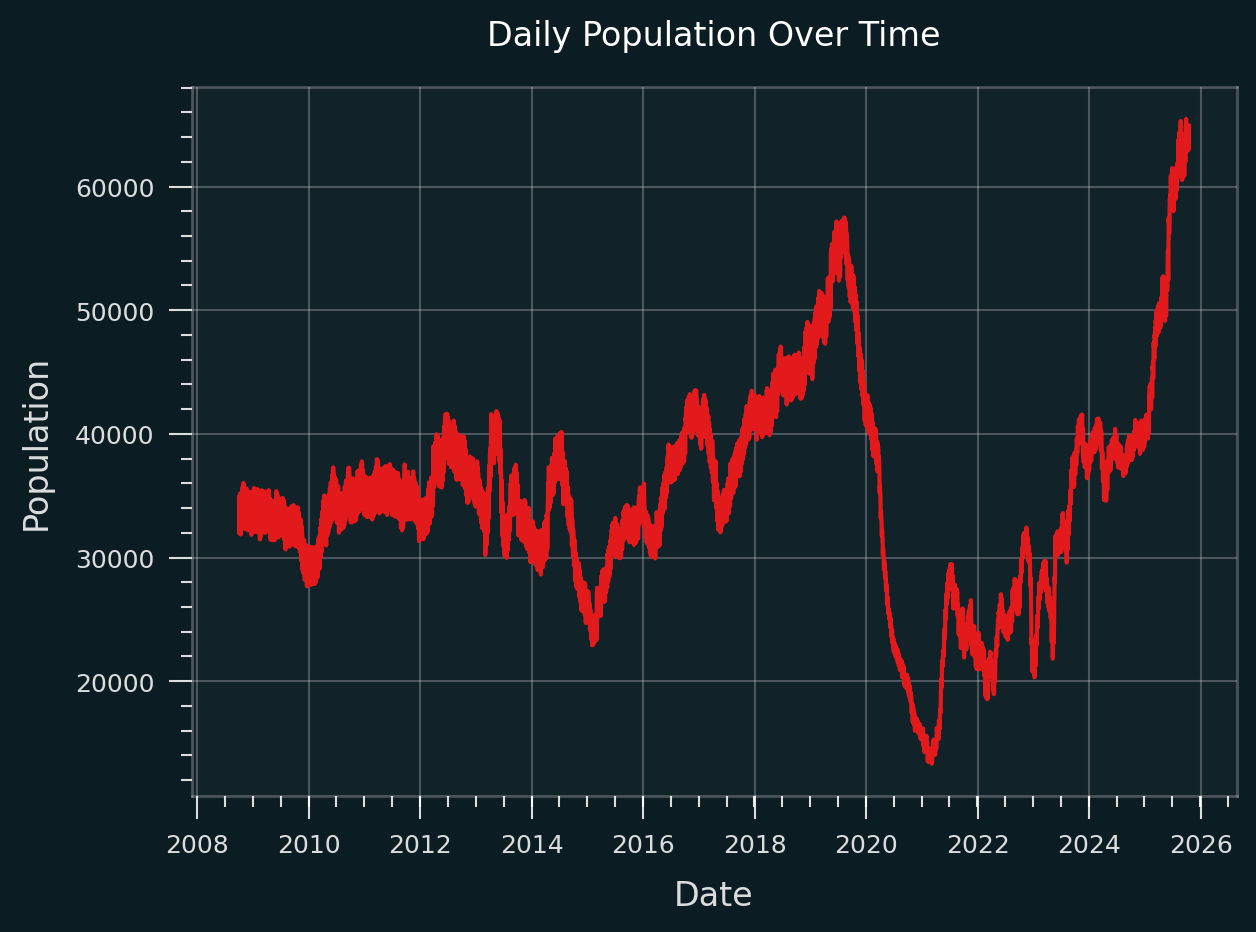

In [41]:
plt.plot(daily.date, daily.daily_pop, label='Daily Population')

plt.title("Daily Population Over Time")
plt.xlabel("Date")
plt.ylabel("Population")
# plt.legend()
plt.tight_layout()
plt.show()


In [30]:
rucc_detention = (
    detention_data[['RUCC', "daily_pop", "midnight_pop", 'daily_change']]
    .groupby(["RUCC"], as_index=False)
    .mean()
    .sort_values("RUCC", ascending=True)
)

rucc_detention


,RUCC,daily_pop,midnight_pop,daily_change
0,1.0,27.35,25.55,1.80
1,2.0,20.20,18.80,1.40
2,3.0,12.03,11.27,0.75
3,4.0,29.14,28.14,1.00
4,5.0,1.25,0.95,0.29
5,6.0,56.36,54.51,1.85
6,7.0,12.79,12.26,0.53
7,8.0,55.64,53.66,1.98
8,9.0,13.84,13.21,0.63


In [58]:
daily_rucc = (
    detention_data[
        ["date", "RUCC","daily_pop", "midnight_pop", "daily_change"]
    ]
    .groupby(["RUCC", "date"], as_index=False)
    .sum()
    .sort_values(["RUCC", "date"], ascending=True)
)

daily_rucc


,RUCC,date,daily_pop,midnight_pop,daily_change
0,1.00,2008-10-01,16234.00,14463.00,1771.00
1,1.00,2008-10-02,16326.00,14383.00,1943.00
2,1.00,2008-10-03,16132.00,14215.00,1917.00
3,1.00,2008-10-04,14702.00,14257.00,445.00
4,1.00,2008-10-05,14598.00,14469.00,129.00
...,...,...,...,...,...
56011,9.00,2025-10-11,1184.00,1167.00,17.00
56012,9.00,2025-10-12,1266.00,1247.00,19.00
56013,9.00,2025-10-13,1278.00,1277.00,1.00
56014,9.00,2025-10-14,1324.00,1280.00,44.00


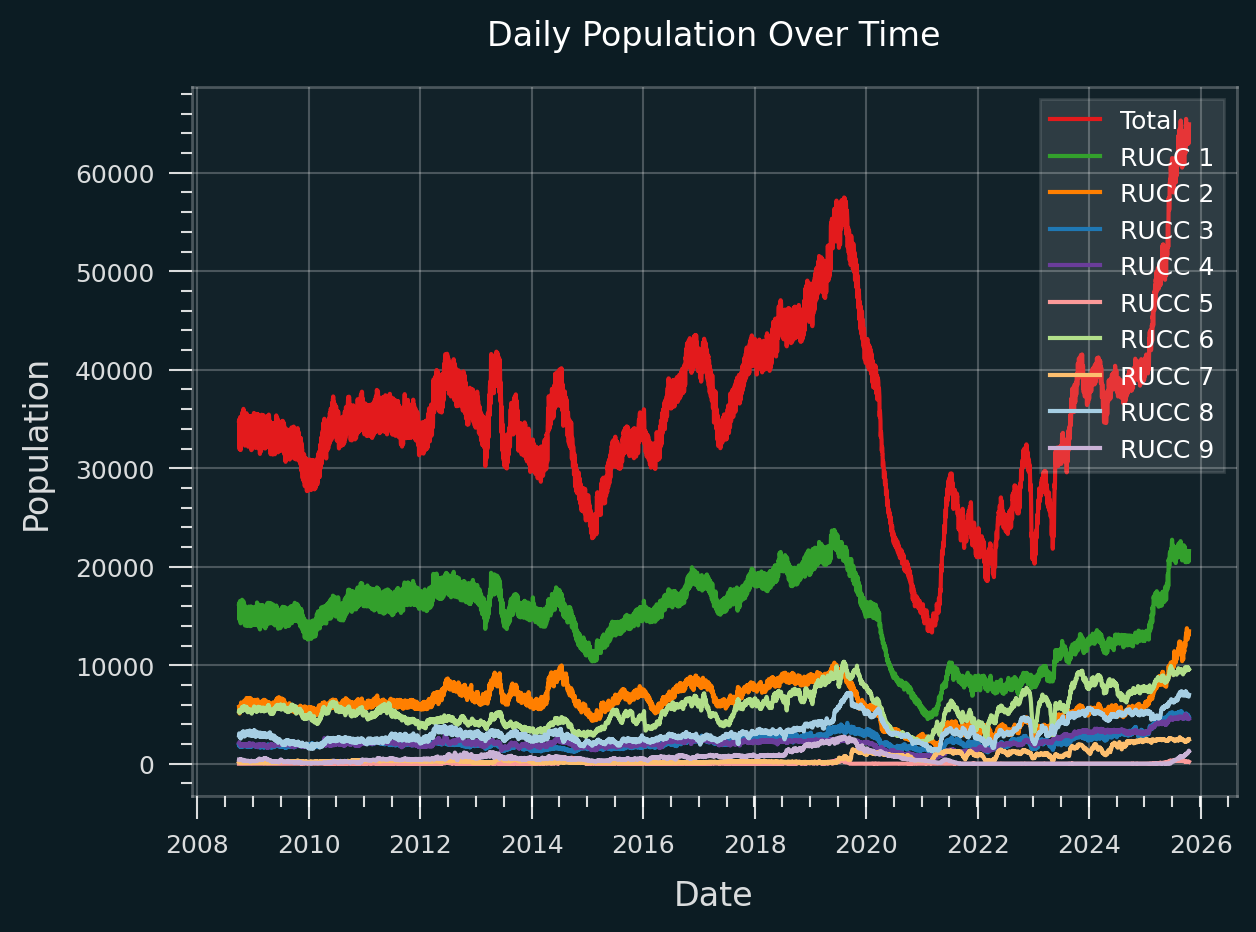

In [ ]:
plt.plot(daily.date, daily.daily_pop, label=f"Total")

for i in range(1,10):
    x = daily_rucc[daily_rucc['RUCC'] == i]
    plt.plot(x.date, x.daily_pop, label=f"RUCC {i}")

plt.title("Daily Population Over Time")
plt.xlabel("Date")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
monthly_rucc = (
    detention_data[
        ["RUCC", "year", "month", "daily_pop", "midnight_pop", "daily_change"]
    ]
    .groupby(["RUCC", "year", "month"], as_index=False)
    .mean()
    .sort_values(["RUCC", "year", "month"], ascending=True)
)
monthly_rucc


,RUCC,year,month,daily_pop,midnight_pop,daily_change
0,1.00,2008.00,10.00,29.20,26.57,2.63
1,1.00,2008.00,11.00,27.97,25.80,2.17
2,1.00,2008.00,12.00,28.13,25.81,2.32
3,1.00,2009.00,1.00,28.24,25.97,2.27
4,1.00,2009.00,2.00,27.98,25.43,2.55
...,...,...,...,...,...,...
1840,9.00,2025.00,6.00,2.28,2.17,0.11
1841,9.00,2025.00,7.00,9.64,9.37,0.27
1842,9.00,2025.00,8.00,16.79,16.30,0.49
1843,9.00,2025.00,9.00,21.85,21.48,0.37


In [78]:
daily_rucc_avg = (
    daily_rucc[["RUCC", "daily_pop", "midnight_pop", "daily_change"]]
    .groupby("RUCC")
    .mean()
)

# 2. Define the columns you want to normalize
cols = ["daily_pop", "midnight_pop", "daily_change"]

# 3. Divide the columns by their horizontal sum (row-wise)
daily_rucc_avg[cols] = daily_rucc_avg[cols].div(
    daily_rucc_avg[cols].sum(axis=0), axis=1
)

daily_rucc_avg


,daily_pop,midnight_pop,daily_change
RUCC,,,
1.00,0.42,0.41,0.49
2.00,0.18,0.17,0.22
3.00,0.06,0.06,0.07
4.00,0.06,0.06,0.04
5.00,0.00,0.00,0.01
6.00,0.16,0.16,0.09
7.00,0.02,0.02,0.01
8.00,0.09,0.09,0.06
9.00,0.01,0.02,0.01
